# Function 1

## Check sys.path

In [1]:
# Checking that PYTHONPATH has been set to include local modules and included with sys.path

import os
try:
    print(f'PYTHONPATH:\n{os.environ['PYTHONPATH'].split(os.pathsep)}')
except KeyError:
    pass

import sys
print(f'\nsys.path:\n{'\n'.join(sys.path)}')

PYTHONPATH:
['C:\\Users\\antho\\Git\\LearningPython\\']

sys.path:
C:\Users\antho\Git\LearningPython
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\python314.zip
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\DLLs
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages


## Imports

In [2]:
# Load extension to auto re-import script changes without having to restart Python kernel 
%load_ext autoreload

# Set autoreload = 2 (reloads everything before every cell execution)
%autoreload 2

# Import scripts common across all BBOFunction notebooks. '%run' ensures variables/imports become part of this notebook's namespace
%run imports.py

## Function 1 Description

*Detect likely contamination sources in a two-dimensional area, such as a radiation field, where only proximity yields a non-zero reading. The system uses Bayesian optimisation to tune detection parameters and reliably identify both strong and weak sources.*

## BBO parameters

In [3]:
func_no = 1
sub_week = 13

display(Markdown(f'**function number:** {func_no}'))
display(Markdown(f'**submission week:** {sub_week}'))

**function number:** 1

**submission week:** 13

## Load data

In [4]:
initial_len, y_pred, x_dim, x_col_names, df = data_helper.get_data(func_no, sub_week)

initial data points: 10
initial max: 7.710875114502849e-16
submission data points: 12
current max: 1.4889788133143885e-10 (from submission week: 5)
x_dim: 2


<br>**DataFrame:**

          x1        x2              y
14  0.670000  0.733000   1.488979e-10
20  0.669950  0.732995   1.467697e-10
18  0.670000  0.735000   6.532695e-11
21  0.668363  0.733000   4.659203e-11
17  0.700000  0.733000   7.232368e-12
2   0.731024  0.733000   7.710875e-16
7   0.683418  0.861057   2.535001e-40
1   0.574329  0.879898   1.033078e-46
9   0.883890  0.582254   6.229856e-48
0   0.319404  0.762959   1.322677e-79
8   0.082507  0.403488   3.606771e-81
3   0.840353  0.264732  3.341771e-124
16  0.991000  0.100000  1.834251e-286
15  0.189999  0.733001 -2.097837e-105
6   0.312691  0.078723  -2.089093e-91
5   0.410437  0.147554  -2.159249e-54
10  0.796278  0.744559  -1.624548e-30
13  0.465030  0.732995  -6.823036e-27
12  0.731024  0.785036  -5.552283e-25
11  0.730507  0.785036  -6.767263e-25
19  0.660000  0.731000  -3.686322e-09
4   0.650114  0.681526  -3.606063e-03


### Manually omit columns or other data amends (if desired)

In [5]:
display(Markdown(f'<span style="color:red">**Warning: Manual data amends is ON**</span>'))

#x_col_names = ["x2", "x3"]
#print(x_col_names)

#x_dim = len(x_col_names)

# Adjusting the size of the huge negative value
df.at[4, 'y'] = -3.606063e-10 # Index = 4, column 'y'
print(df)

<span style="color:red">**Warning: Manual data amends is ON**</span>

          x1        x2              y
14  0.670000  0.733000   1.488979e-10
20  0.669950  0.732995   1.467697e-10
18  0.670000  0.735000   6.532695e-11
21  0.668363  0.733000   4.659203e-11
17  0.700000  0.733000   7.232368e-12
2   0.731024  0.733000   7.710875e-16
7   0.683418  0.861057   2.535001e-40
1   0.574329  0.879898   1.033078e-46
9   0.883890  0.582254   6.229856e-48
0   0.319404  0.762959   1.322677e-79
8   0.082507  0.403488   3.606771e-81
3   0.840353  0.264732  3.341771e-124
16  0.991000  0.100000  1.834251e-286
15  0.189999  0.733001 -2.097837e-105
6   0.312691  0.078723  -2.089093e-91
5   0.410437  0.147554  -2.159249e-54
10  0.796278  0.744559  -1.624548e-30
13  0.465030  0.732995  -6.823036e-27
12  0.731024  0.785036  -5.552283e-25
11  0.730507  0.785036  -6.767263e-25
19  0.660000  0.731000  -3.686322e-09
4   0.650114  0.681526  -3.606063e-10


## Distance between x points

In [6]:
dists, min_dist, max_dist = distance_helper.distances_between_points(x = df[x_col_names].values)

#display(Markdown('**Distances between x points:**'))
#for row in dists:
#    print(f'{row}')

display(Markdown(f'**min_dist:** {min_dist}'))
display(Markdown(f'**max_dist:** {max_dist}'))

**min_dist:** 5e-05

**max_dist:** 1.020927

## Tune Gaussian Process surrogate model

### Setup hyperparameters to trial (kernels, x_tansform and y_transform)

In [7]:
kernels = gaussian_process_helper.get_kernels(x_dim)

print(kernels.keys())

dict_keys(['Matern 2.5', 'Matern 1.5', 'Matern 0.5', 'RBF', 'Rational Quad', 'Periodic', 'Locally Periodic', 'Linear + RBF', 'Matern 2.5 + WhiteK', 'Matern 1.5 + WhiteK', 'Matern 0.5 + WhiteK', 'RBF + WhiteK', 'Rational Quad + WhiteK', 'Periodic + WhiteK', 'Locally Periodic + WhiteK', 'Linear + RBF + WhiteK', 'Local Sens + Mat 2.5 + WhiteK', 'Ridge + RQ + WhiteK', 'Local Sens + Ridge + Mat 2.5 + WhiteK'])


In [8]:
y_transforms = transform_helper.get_y_transformers(inc_symlog = True)

print(y_transforms.keys())

dict_keys(['none', 'scaled', 'power', 'pow-scaled', 'logshift', 'logshift-scaled', 'symlog', 'symlog-scaled'])


In [9]:
x_transforms = transform_helper.get_x_transformers()

print(x_transforms.keys())

dict_keys(['none', 'scaled'])


### Manually override hyperparameter options (if desired)

### Perform the hyperparameter tuning

In [10]:
df_tuning_results, model_dict = gaussian_process_helper.tune_gaussian_process_surrogate(
    df = df,
    x_col_names = x_col_names,
    kernels = kernels,
    y_transforms = y_transforms,
    x_transforms = x_transforms,
)


Matern 2.5, x:none, y:none...
              y_t        mean_t       resid_t     std_t        y_pred
14   1.488979e-10 -2.263965e-10 -3.752943e-10  0.000103 -2.263965e-10
20   1.467697e-10 -2.262571e-10 -3.730269e-10  0.000103 -2.262571e-10
18   6.532695e-11 -2.219082e-10 -2.872352e-10  0.000103 -2.219082e-10
21   4.659203e-11 -2.199145e-10 -2.665065e-10  0.000103 -2.199145e-10
17   7.232368e-12 -2.223130e-10 -2.295454e-10  0.000103 -2.223130e-10
2    7.710875e-16 -2.268917e-10 -2.268924e-10  0.000103 -2.268917e-10
7    2.535001e-40 -2.612077e-10 -2.612077e-10  0.000105 -2.612077e-10
1    1.033078e-46 -2.531959e-10 -2.531959e-10  0.000105 -2.531959e-10
9    6.229856e-48 -2.146705e-10 -2.146705e-10  0.000107 -2.146705e-10
0    1.322677e-79 -1.919260e-10 -1.919260e-10  0.000108 -1.919260e-10
8    3.606771e-81 -5.319775e-11 -5.319775e-11  0.000121 -5.319775e-11
3   3.341771e-124 -1.235298e-10 -1.235298e-10  0.000112 -1.235298e-10
16  1.834251e-286 -1.096338e-10 -1.096338e-10  0.000131 -1.

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


         y_t        mean_t   resid_t     std_t        y_pred
14  0.405832  4.092114e-01  0.003379  0.008323  1.515123e-10
20  0.403082  3.986614e-01 -0.004420  0.008111  1.433497e-10
18  0.297818 -1.221554e-02 -0.310034  1.046426 -1.745470e-10
21  0.273603  3.977049e-01  0.124101  0.083875  1.426097e-10
17  0.222732  6.308242e-01  0.408092  0.847736  3.229748e-10
2   0.213385 -6.026549e-02 -0.273650  0.978222 -2.117234e-10
7   0.213384  0.000000e+00 -0.213384  1.054005 -1.650958e-10
1   0.213384  0.000000e+00 -0.213384  1.054005 -1.650958e-10
9   0.213384  0.000000e+00 -0.213384  1.054005 -1.650958e-10
0   0.213384  0.000000e+00 -0.213384  1.054005 -1.650958e-10
8   0.213384  0.000000e+00 -0.213384  1.054005 -1.650958e-10
3   0.213384  0.000000e+00 -0.213384  1.054005 -1.650958e-10
16  0.213384  0.000000e+00 -0.213384  1.054005 -1.650958e-10
15  0.213384  2.017989e-10 -0.213384  1.054005 -1.650958e-10
6   0.213384  0.000000e+00 -0.213384  1.054005 -1.650958e-10
5   0.213384  0.000000e+

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


         y_t        mean_t   resid_t     std_t        y_pred
14  1.820181  1.815576e+00 -0.004605  0.011192  1.485879e-10
20  1.788555  1.792463e+00  0.003909  0.010942  1.470326e-10
18  0.716601  1.050916e+00  0.334314  0.778089  8.695362e-11
21  0.504527  7.163540e-01  0.211827  0.309963  6.424472e-11
17  0.095562  1.379623e-06 -0.095561  0.986593 -2.201654e-11
2   0.025473  1.953093e-08 -0.025473  0.986593 -2.201670e-11
7   0.025467  3.469447e-18 -0.025467  0.986593 -2.201671e-11
1   0.025467  3.469447e-18 -0.025467  0.986593 -2.201671e-11
9   0.025467  3.469447e-18 -0.025467  0.986593 -2.201671e-11
0   0.025467  3.469447e-18 -0.025467  0.986593 -2.201671e-11
8   0.025467  3.469447e-18 -0.025467  0.986593 -2.201671e-11
3   0.025467  3.469447e-18 -0.025467  0.986593 -2.201671e-11
16  0.025467  3.469447e-18 -0.025467  0.986593 -2.201671e-11
15  0.025467  3.469447e-18 -0.025467  0.986593 -2.201671e-11
6   0.025467  3.469447e-18 -0.025467  0.986593 -2.201671e-11
5   0.025467  3.469447e-

...

             y_t        mean_t       resid_t     std_t        y_pred
14  1.871777e-10 -1.388359e-11 -2.010612e-10  0.000326  4.429951e-09
20  1.838792e-10 -1.367853e-11 -1.975577e-10  0.000326  4.429950e-09
18  7.208108e-11 -6.757553e-12 -7.883863e-11  0.000326  4.430004e-09
21  4.996301e-11 -5.384638e-12 -5.534764e-11  0.000326  4.429926e-09
17  7.310524e-12 -2.569335e-12 -9.879859e-12  0.000327  4.430600e-09
2   6.661345e-16 -1.877797e-12 -1.878463e-12  0.000328  4.431661e-09
7   0.000000e+00 -9.876547e-13 -9.876547e-13  0.000333  4.437082e-09
1   0.000000e+00 -1.511087e-12 -1.511087e-12  0.000335  4.438852e-09
9   0.000000e+00 -2.086189e-12 -2.086189e-12  0.000338  4.442661e-09
0   0.000000e+00 -3.870341e-12 -3.870341e-12  0.000344  4.448436e-09
8   0.000000e+00 -8.079099e-12 -8.079099e-12  0.000389  4.489339e-09
3   0.000000e+00 -4.534123e-12 -4.534123e-12  0.000357  4.460309e-09
16  0.000000e+00 -5.511396e-12 -5.511396e-12  0.000425  4.519406e-09
15  0.000000e+00 -4.858363e-12 -4.

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k2__sigma_0 is close to the specified lower bound 1e-07. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a be

              y_t        mean_t       resid_t     std_t        y_pred
14   1.488979e-10 -3.584247e-10 -5.073226e-10  0.000330 -3.584247e-10
20   1.467697e-10 -3.583082e-10 -5.050779e-10  0.000330 -3.583082e-10
18   6.532695e-11 -3.479158e-10 -4.132428e-10  0.000330 -3.479158e-10
21   4.659203e-11 -3.512977e-10 -3.978898e-10  0.000331 -3.512977e-10
17   7.232368e-12 -3.008873e-10 -3.081197e-10  0.000330 -3.008873e-10
2    7.710875e-16 -2.505457e-10 -2.505465e-10  0.000332 -2.505457e-10
7    2.535001e-40 -1.361683e-10 -1.361683e-10  0.000362 -1.361683e-10
1    1.033078e-46 -1.844610e-10 -1.844610e-10  0.000381 -1.844610e-10
9    6.229856e-48 -1.084490e-10 -1.084490e-10  0.000410 -1.084490e-10
0    1.322677e-79 -1.341168e-10 -1.341168e-10  0.000386 -1.341168e-10
8    3.606771e-81  5.409726e-11  5.409726e-11  0.000562  5.409726e-11
3   3.341771e-124 -1.628780e-10 -1.628780e-10  0.000423 -1.628780e-10
16  1.834251e-286  2.295510e-10  2.295510e-10  0.000669  2.295510e-10
15 -2.097837e-105  3

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k2__sigma_0 is close to the specified lower bound 1e-07. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a be

             y_t        mean_t       resid_t     std_t        y_pred
14  1.871777e-10 -2.548970e-11 -2.126674e-10  0.000330  4.434641e-09
20  1.838792e-10 -2.519794e-11 -2.090771e-10  0.000330  4.434644e-09
18  7.208108e-11 -1.447071e-11 -8.655180e-11  0.000330  4.434500e-09
21  4.996301e-11 -1.312128e-11 -6.308428e-11  0.000331  4.434745e-09
17  7.310524e-12 -5.323496e-12 -1.263402e-11  0.000330  4.434071e-09
2   6.661345e-16 -1.150084e-12 -1.150750e-12  0.000332  4.436378e-09
7   0.000000e+00  1.689458e-11  1.689458e-11  0.000362  4.465190e-09
1   0.000000e+00  1.069209e-11  1.069209e-11  0.000381  4.482327e-09
9   0.000000e+00 -1.364887e-12 -1.364887e-12  0.000410  4.507670e-09
0   0.000000e+00 -8.034296e-12 -8.034296e-12  0.000386  4.486638e-09
8   0.000000e+00 -1.045882e-12 -1.045882e-12  0.000562  4.613686e-09
3   0.000000e+00 -1.814354e-11 -1.814354e-11  0.000423  4.517885e-09
16  0.000000e+00  1.394577e-11  1.394577e-11  0.000669  4.672732e-09
15  0.000000e+00  2.046416e-13  2.

## Analytical Leave-One-Out Cross-Validation (LOOCV) Model Results 

In [11]:
# Sort df_tuning_results:
# Mean-Square_Error (MSE) - The "best" kernel is the one with the lowest MSE    
# Log-Marginal Likelihood (LML) - The "best" kernel is the one with the highest LML
sort_columns = [Y_SMSE_TOP, Y_SMSE, Z_SMSE, LML]
sort_orders  = [      True,   True,   True, False]

#sort_columns = [Y_SMSE, Z_SMSE, LML]
#sort_orders  = [  True,   True, False]

df_tuning_results_sorted = df_tuning_results.sort_values(by=sort_columns, ascending=sort_orders)

# Format numeric display columns
display_cols = [MODEL, Z_SMSE, Y_SMSE, Y_SMSE_TOP, LML, KERNEL_PARAMS ]
for col in display_cols:
    df_tuning_results_sorted[col] = df_tuning_results_sorted[col].apply(format_sig_figs)

print(df_tuning_results_sorted[display_cols].to_string(index=False))

                                                             Model   Z_SMSE      Y_SMSE  Y_SMSE_TOP      LML                                                                                                                                                      Kernel_Params
                              RBF + WhiteK, x:scaled, y:pow-scaled 0.672234     1.02866 0.000424739 -23.6201                                                                                                  0.977**2 * RBF(len_scale=[0.0116, 0.00739]) + WhiteK(noise=1e-07)
                                RBF + WhiteK, x:none, y:pow-scaled 0.672234     1.02866 0.000424739 -23.6201                                                                                                 0.977**2 * RBF(len_scale=[0.00256, 0.00179]) + WhiteK(noise=1e-07)
                 Locally Periodic + WhiteK, x:scaled, y:pow-scaled 0.672234     1.02866 0.000424741 -23.6201                                       0.977**2 * RBF(len_scale=[0.0116, 0.0

## LOOCV Detailed Results for best model (Optionally override auto selected best model)

In [12]:
best_model_name = df_tuning_results_sorted[MODEL].iloc[0]

# Manually overriding best_model (optional)
override_model_name = "Locally Periodic + WhiteK, x:none, y:symlog" # None

if not override_model_name is None:
    display(Markdown(f'<span style="color:red">**Warning: Manually overriding best model from "{best_model_name}" to "{override_model_name}"**</span>'))
    best_model_name = override_model_name
    
best_model_dict = model_dict[best_model_name]
best_model = best_model_dict[MODEL]
x_transform = best_model_dict[X_TRANSFORM]
y_transform = best_model_dict[Y_TRANSFORM]

display(Markdown(f'<br>**Best model:**<br>{best_model_name}'))

params_str = extract_optimised_kernel_params_str(best_model)
display(Markdown(f'**Optimised parameters:**'))
print(params_str) # Own print() since it contains **

best_loocv_results = best_model_dict[LOOCV]

# Add the best model LOOCV results to df for easier display 
for label, content in best_loocv_results.items():
    df[label] = content

display(Markdown(f'<br>**LOOCV Predictions using best model:**<br>'))
print(df)

<span style="color:red">**Warning: Manually overriding best model from "RBF + WhiteK, x:scaled, y:pow-scaled" to "Locally Periodic + WhiteK, x:none, y:symlog"**</span>

<br>**Best model:**<br>Locally Periodic + WhiteK, x:none, y:symlog

**Optimised parameters:**

0.802**2 * RBF(len_scale=[0.014, 1.94e+03]) * ExpSineSquared(len_scale=0.495, periodicity=0.0666) + WhiteK(noise=1e-07)


<br>**LOOCV Predictions using best model:**<br>

          x1        x2              y            y_t        mean_t  \
14  0.670000  0.733000   1.488979e-10   7.146419e-01  7.158887e-01   
20  0.669950  0.732995   1.467697e-10   7.073168e-01  7.060852e-01   
18  0.670000  0.735000   6.532695e-11   3.769297e-01  4.936676e-01   
21  0.668363  0.733000   4.659203e-11   2.825516e-01  3.209685e-01   
17  0.700000  0.733000   7.232368e-12   4.944080e-02  9.196280e-02   
2   0.731024  0.733000   7.710875e-16   5.403655e-06  8.508568e-04   
7   0.683418  0.861057   2.535001e-40   1.776492e-30 -1.378135e-01   
1   0.574329  0.879898   1.033078e-46   7.239663e-37 -4.157142e-08   
9   0.883890  0.582254   6.229856e-48   4.365793e-38 -1.702361e-15   
0   0.319404  0.762959   1.322677e-79   9.269130e-70  4.022790e-33   
8   0.082507  0.403488   3.606771e-81   2.527573e-71  1.395674e-63   
3   0.840353  0.264732  3.341771e-124  2.341865e-114  2.415438e-12   
16  0.991000  0.100000  1.834251e-286  1.285417e-276  1.816622e-31   
15  0.189999  0.7330

## y and y_t (y transformed) plots

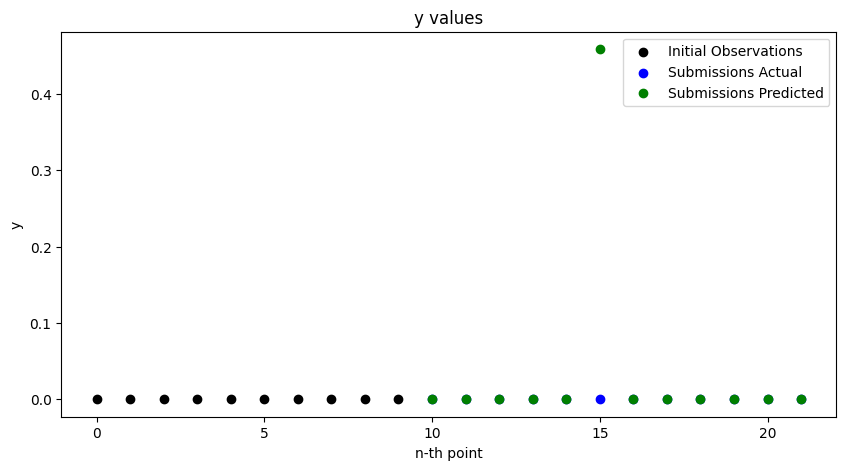

In [13]:
plot_helper.sequence_plot(df["y"], initial_len, y_pred)

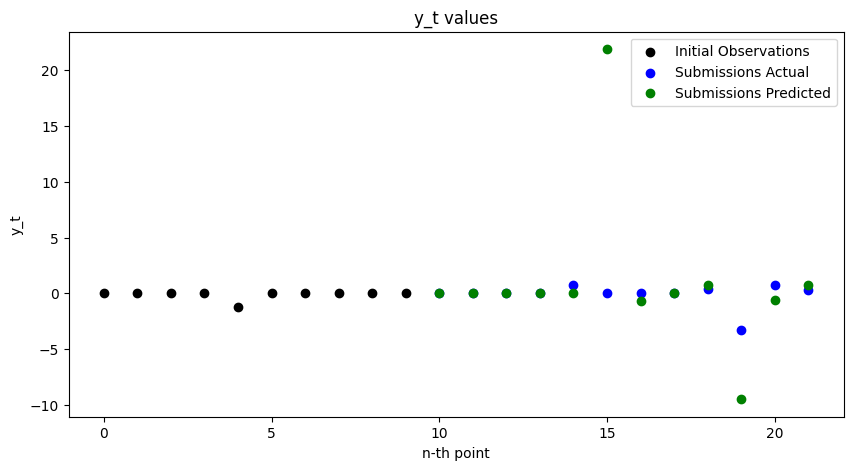

In [14]:
y_t_pred = y_transform.transform(y_pred)
plot_helper.sequence_plot(df["y_t"], initial_len, y_t_pred)

## Determine next evaluation point

### Create grid

In [15]:
x_grid = grid_helper.hypercube_grid([250, 250], x_col_names)

#print(x_grid[0:5])

len(x_grid): 63001


### Maximise UCB and EI acquisition functions

In [16]:
# Small xi (0.0 – 0.01) - Exploitation dominant
# Moderate xi (0.01 – 0.1) - Balanced
# Large xi (0.5+) Strong exploration
ei_xis = [ 2, 1, 0.5, 0.1, 0.05, 0.01, 0.005, 0.001, 0 ]
ucb_betas = [ 10, 5, 2, 1, 0.5, 0.1, 0.05, 0.01, 0 ]
acq_fns = acquisition_fns_helper.get_acq_fns(df, y_transform, ei_xis = ei_xis, ucb_betas = ucb_betas)

# Bespoke bounds to force suggested next x near current x_best:
override_bounds = None # E.g. [(0.5, 0.9), (0.1, 0.4), ...]

if not override_bounds is None:
    display(Markdown(f'<span style="color:red">**Warning: Manually overriding acquisition function optimisation bounds to "{override_bounds}"**</span>'))
    
df_acq_results = acquisition_fns_helper.determine_next_eval_points(df, best_model, x_grid, x_col_names, x_transform, y_transform, x_dim, acq_fns, bounds = override_bounds, opt_trials=1000)

EI trans space (xi=2)...


C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\_gpr.py:490: UserWarning: Predicted variances smaller than 0. Setting those variances to 0.
  warnings.warn(


Acq Fn([0.67122821 0.7204594 ]) = 9.328007528302293e-05, distance: 0.012600602187706719, y_t_best: [0.15050376], y_best: [4.54195214e-11]
EI trans space (xi=1)...
Acq Fn([0.67105378 0.72455642]) = 0.007421843528459017, distance: 0.008509078461356342, y_t_best: [0.495742], y_best: [1.37975279e-10]
EI trans space (xi=0.5)...
Acq Fn([0.67137809 0.72750552]) = 0.05438298367124597, distance: 0.0056646650114190525, y_t_best: [0.8641284], y_best: [2.30787458e-10]
EI trans space (xi=0.1)...
Acq Fn([0.67151533 0.72954328]) = 0.23976628310775766, distance: 0.0037742744355259055, y_t_best: [1.01948221], y_best: [2.67511337e-10]
EI trans space (xi=0.05)...
Acq Fn([0.67150748 0.72973754]) = 0.2804274988859839, distance: 0.003593901195957305, y_t_best: [1.0251354], y_best: [2.68001546e-10]
EI trans space (xi=0.01)...
Acq Fn([0.67149994 0.72986674]) = 0.3153340293332183, distance: 0.003473775782702777, y_t_best: [1.02786138], y_best: [2.67967659e-10]
EI trans space (xi=0.005)...
Acq Fn([0.671499   0.

### Display the acquisition function results

In [17]:
display(Markdown(f'<br>**EXISTING BEST:**'))
print(f'Actual y: {df['y'].iloc[0]}\nActual y_t: {df['y_t'].iloc[0]}\nx: {df[x_col_names].iloc[0].values}')

y_t_mean, y_t_std = best_model.predict(np.atleast_2d(df[x_col_names].iloc[0].values), return_std=True)
y_mean, y_std = y_transform.inverse_transform_dist(y_t_mean, y_t_std)

display(Markdown(f'<br>**Model\'s [{best_model_name}] prediction at x corresponding to the best y.**'))
print(f'NB. the model was already trained using this x point. This is just a sense check for modelling accuracy rather than predictive ability.')
print(f'y_t_mean: {y_t_mean}, y_t_std: {y_t_std}\ny_mean: {y_mean}\n')

# Add a y_mean ranking
df_acq_results['y_mean rank'] = df_acq_results['y_mean'].rank(ascending=False, method='min').astype(int)

display(Markdown(f'<br>**FUNCTION {func_no} SUBMISSION WEEK {sub_week}:**<br>'))
print(df_acq_results.to_string(index=False))

<br>**EXISTING BEST:**

Actual y: 1.4889788133143885e-10
Actual y_t: 0.7146419335295893
x: [0.67  0.733]


<br>**Model's [Locally Periodic + WhiteK, x:none, y:symlog] prediction at x corresponding to the best y.**

NB. the model was already trained using this x point. This is just a sense check for modelling accuracy rather than predictive ability.
y_t_mean: [0.71467862], y_t_std: [0.00044391]
y_mean: [1.48908607e-10]



<br>**FUNCTION 1 SUBMISSION WEEK 13:**<br>

                     acq_fn      ['x1', 'x2']  distance     y_t_mean       y_mean  y_mean rank
      EI trans space (xi=2) 0.671228-0.720459  0.012601 1.505038e-01 4.541952e-11           17
      EI trans space (xi=1) 0.671054-0.724556  0.008509 4.957420e-01 1.379753e-10           16
    EI trans space (xi=0.5) 0.671378-0.727506  0.005665 8.641284e-01 2.307875e-10           14
    EI trans space (xi=0.1) 0.671515-0.729543  0.003774 1.019482e+00 2.675113e-10            6
   EI trans space (xi=0.05) 0.671507-0.729738  0.003594 1.025135e+00 2.680015e-10            1
   EI trans space (xi=0.01) 0.671500-0.729867  0.003474 1.027861e+00 2.679677e-10            2
  EI trans space (xi=0.005) 0.671499-0.729881  0.003460 1.028112e+00 2.679458e-10            3
  EI trans space (xi=0.001) 0.671498-0.729892  0.003450 1.028300e+00 2.679263e-10            4
      EI trans space (xi=0) 0.671498-0.729895  0.003447 1.028345e+00 2.679211e-10            5
       EI orig space (xi=2) 0.988000-0.068000  0.0

## Plot new point

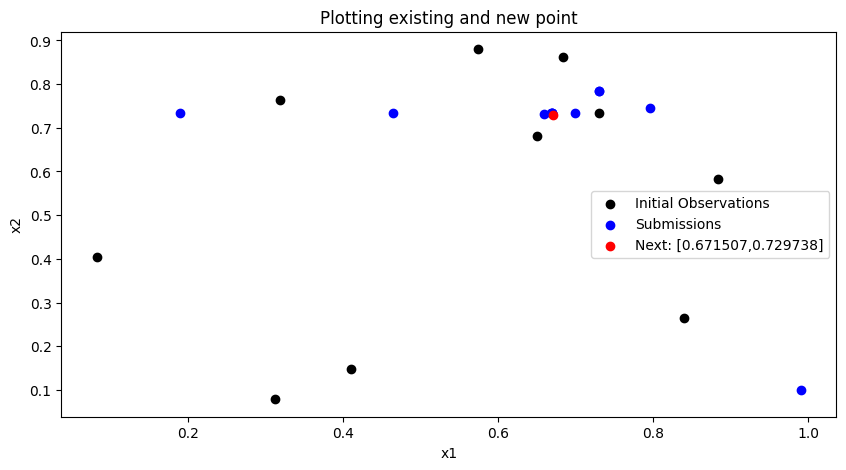

In [18]:
import matplotlib.pyplot as plt

x_best = [0.671507, 0.729738]

df_index_sorted = df.sort_index()

x1 = df_index_sorted["x1"]
x2 = df_index_sorted["x2"]

plt.figure(figsize=(10, 5))
plt.scatter(x1[:initial_len], x2[:initial_len], c='k', label='Initial Observations')  # 'k' = black
plt.scatter(x1[initial_len:], x2[initial_len:], c='b', label='Submissions') # 'b' = blue
plt.scatter([x_best[0]], [x_best[1]], c='r', label=f'Next: [{x_best[0]:.6f},{x_best[1]:.6f}]')  
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.title(f'Plotting existing and new point')
plt.show()

## Manually calculating the prediction at an x point (Helper method)